In [4]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:

print(df.info())
print("\n各欄位缺失值統計：")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

各欄位缺失值統計：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                                    
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:

age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

most_frequent_port = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_frequent_port)

df_cleaned = df.drop(columns=['Cabin', 'Name', 'Ticket'])


print("=== 清理後的缺失值統計 ===")
for col, val in df_cleaned.isnull().sum().items():
    print(f"{col}: {val}")


=== 清理後的缺失值統計 ===
PassengerId: 0
Survived: 0
Pclass: 0
Sex: 0
Age: 0
SibSp: 0
Parch: 0
Fare: 0
Embarked: 0


In [7]:
import pandas as pd

df_cleaned['Sex'] = df_cleaned['Sex'].map({'female': 0, 'male': 1})

df_encoded = pd.get_dummies(df_cleaned, columns=['Embarked'], drop_first=True)

df_encoded = df_encoded.drop(columns=['PassengerId'])

X = df_encoded.drop(columns=['Survived'])
y = df_encoded['Survived']

print("=== 轉換後的特徵欄位 (X) 前 3 筆 ===")
display(X.head(3))


=== 轉換後的特徵欄位 (X) 前 3 筆 ===


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,False,True
1,1,0,38.0,1,0,71.2833,False,False
2,3,0,26.0,0,0,7.9250,False,True


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"=== 模型預測準確度 ===")
print(f"準確率 (Accuracy): {accuracy:.2%}\n")

print("=== 詳細分類報告 ===")
print(classification_report(y_test, y_pred))


=== 模型預測準確度 ===
準確率 (Accuracy): 81.01%

=== 詳細分類報告 ===
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



C:\Users\user\AppData\Local\Temp\ipykernel_30628\1434848753.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis', ax=ax[1])


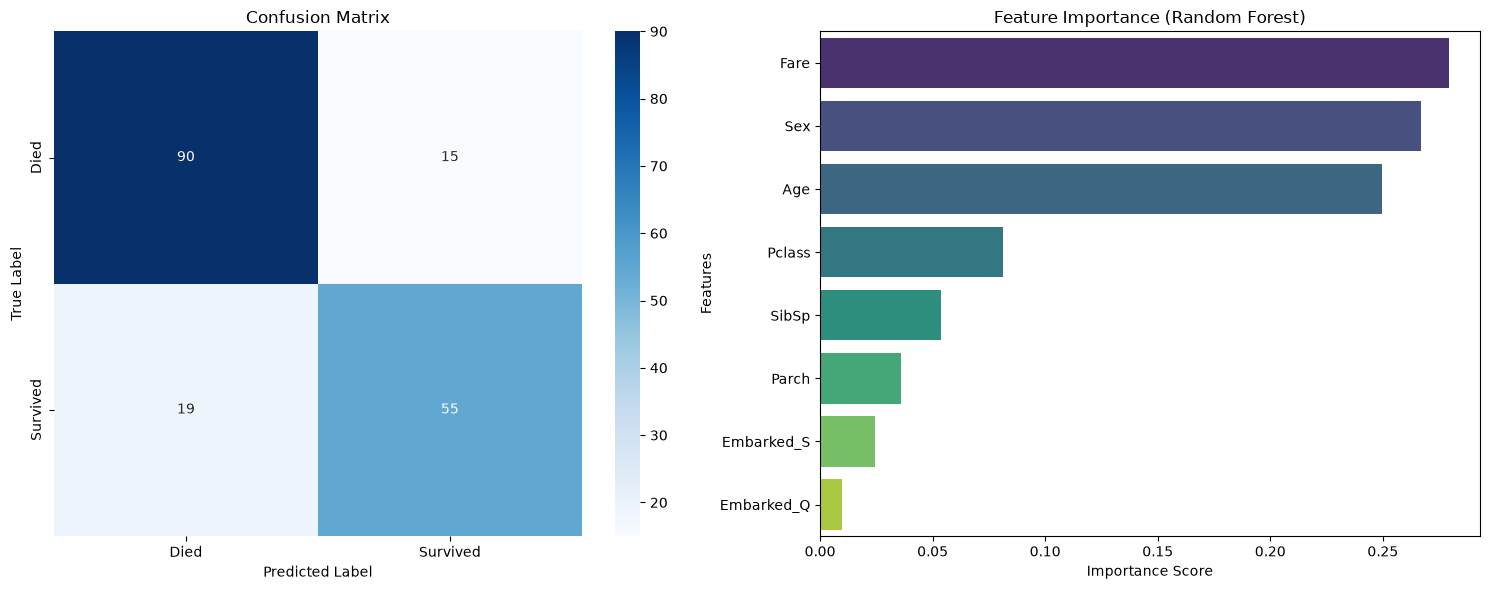

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
ax[0].set_title('Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

sns.barplot(x=importances[indices], y=features[indices], palette='viridis', ax=ax[1])
ax[1].set_title('Feature Importance (Random Forest)')
ax[1].set_xlabel('Importance Score')
ax[1].set_ylabel('Features')

plt.tight_layout()
plt.show()
